# **Credit Card Marketing Mix Modeling & ROI Analysis**

In today’s competitive financial services landscape, acquiring new credit card customers efficiently through digital marketing channels is critical for business growth. However, marketing budgets are often spread across multiple channels without a clear understanding of which ones deliver the best return on investment (ROI).

# **The Problem:**
Financial institutions struggle to accurately measure the impact of their marketing spend on credit card application approvals across various digital touchpoints. Without this insight, budgets may be misallocated, leading to higher customer acquisition costs and missed growth opportunities.

**What We Are Going to Do:**
This project uses **Marketing Mix Modeling (MMM)** — a proven statistical technique — to analyze historical marketing spend and credit card approval data across multiple channels. By building a multivariate regression model, we will quantify the contribution of each channel toward driving approvals.

# **Our Aim:**

* Provide data-driven insights that enable clients to optimize their marketing spend across channels
* Identify the highest-performing channels to maximize approvals while minimizing costs
* Offer actionable recommendations to reallocate budget efficiently and improve overall digital acquisition performance

By delivering a robust, explainable model and clear visualizations, this project empowers marketing teams and business leaders to make informed, strategic decisions that drive sustainable growth in credit card acquisition.

#  **1_simulate_data.py → Simulating Marketing Data**

What it does (technical):

Creates 3 years of weekly data (156 weeks).

Adds baseline approvals (natural sign-ups without marketing).

Adds seasonality (spikes/dips like holidays).

Simulates spends for 7 marketing channels (Product, Credit_Landing, Home, Shopping_Cart, Checkout, Citi_com, Email).

Applies:

Adstock effect → memory of ads (some last longer, e.g. Citi.com, some fade fast, e.g. Email).

Saturation effect → diminishing returns (too much spend gets less effective).

Combines all effects + random noise → Total Approvals.

Saves final dataset → marketing_data.csv.

Layman explanation:
Imagine you’re tracking how Citi runs ads across multiple places (product pages, checkout page, emails). Some ads people remember longer, others get boring quickly. This script creates a fake but realistic dataset showing how many credit approvals happen weekly due to these ads + natural demand.

In [ ]:
# 1_simulate_data.py

import pandas as pd
import numpy as np

print("--- Step 1: Simulating Realistic Marketing Data ---")

# --- Configuration ---
np.random.seed(42) # This makes our random numbers predictable for the same run
N_WEEKS = 156 # 3 years of weekly data
CHANNELS = ['Product', 'Credit_Landing', 'Home', 'Shopping_Cart', 'Checkout', 'Citi_com', 'Email']

# --- Let's define the "Secret Rules" of our world ---

# Rule #1: How long does the memory of an ad last? (Adstock)
# 0 means memory fades instantly, 0.9 means it lasts a very long time.
# Email is a direct call to action (low memory), Citi.com is brand-building (high memory).
ADSTOCK_ALPHAS = {
    'Product': 0.3, 'Credit_Landing': 0.5, 'Home': 0.2, 'Shopping_Cart': 0.8,
    'Checkout': 0.6, 'Citi_com': 0.3, 'Email': 0.05
}

# Rule #2: How quickly do people get tired of ads in a channel? (Saturation)
# A low number (e.g., 0.3) means you get tired very fast. A high number (e.g., 0.9) means you can spend a lot before it becomes less effective.
SATURATION_GAMMAS = {
    'Product': 0.7, 'Credit_Landing': 0.6, 'Home': 0.4, 'Shopping_Cart': 0.8,
    'Checkout': 0.7, 'Citi_com': 0.65, 'Email': 0.50
}

# Rule #3: The "True Power" of each channel (The secret coefficients we want to find)
# This is how much 1 unit of (transformed) spend actually increases approvals.
# We'll make Cart the most powerful and Email the least powerful.
TRUE_BETAS = {
    'Product': 0.010, 'Credit_Landing': 0.025, 'Home': 0.005, 'Shopping_Cart': 0.5,
    'Checkout': 0.2, 'Citi_com': 0.015, 'Email': 0.030
}

# --- Build the Dataset Step-by-Step ---

# A. Create a timeline and a baseline of approvals
# This is the number of approvals you get naturally, without any marketing.
data = pd.DataFrame({
    'Date': pd.to_datetime(pd.date_range(start='2021-01-01', periods=N_WEEKS, freq='W')),
    'Baseline_Approvals': np.random.normal(loc=200, scale=15, size=N_WEEKS).astype(int)
})

# B. Add seasonality (like holiday spikes)
data['Time'] = np.arange(N_WEEKS)
data['Seasonality'] = (np.sin(2 * np.pi * data['Time'] / 52) * 50).astype(int)

# C. Generate marketing spend for each channel
for channel in CHANNELS:
    data[f'Spend_{channel}'] = (np.random.gamma(2, 3000, N_WEEKS) + np.random.randint(100, 1000)).astype(int)

# D. Apply the "Secret Rules" to the spend data
# This is the most important part: transforming raw spend into its true impact.

def apply_adstock(spend_series, alpha):
    """Calculates the carryover effect of marketing spend."""
    adstocked_spend = np.zeros_like(spend_series, dtype=float)
    adstocked_spend[0] = spend_series[0]
    for i in range(1, len(spend_series)):
        adstocked_spend[i] = spend_series[i] + alpha * adstocked_spend[i-1]
    return adstocked_spend

def apply_saturation(spend_series, gamma):
    """Calculates the diminishing returns effect."""
    return spend_series ** gamma

# E. Calculate the final number of approvals based on our rules
data['Marketing_Contribution'] = 0
for channel in CHANNELS:
    alpha = ADSTOCK_ALPHAS[channel]
    gamma = SATURATION_GAMMAS[channel]
    beta = TRUE_BETAS[channel]

    # 1. Get the spend for the channel
    spend = data[f'Spend_{channel}']
    # 2. Apply the memory effect (adstock)
    adstocked_spend = apply_adstock(spend, alpha)
    # 3. Apply the "getting tired" effect (saturation)
    saturated_spend = apply_saturation(adstocked_spend, gamma)
    # 4. Calculate the approvals driven by this channel using its "true power"
    data[f'Transformed_{channel}'] = saturated_spend # Save for modeling step
    data['Marketing_Contribution'] += beta * saturated_spend

# F. Add some random noise to make it realistic
random_noise = np.random.normal(loc=0, scale=10, size=N_WEEKS)

# The Final Formula for Total Approvals
data['Total_Approvals'] = (data['Baseline_Approvals'] +
                           data['Seasonality'] +
                           data['Marketing_Contribution'] +
                           random_noise).astype(int)

# G. Save the final dataset for our model
# We only save the columns a real analyst would see: Date, Spends, and Total Approvals
columns_to_save = ['Date', 'Total_Approvals', 'Seasonality'] + [f'Spend_{c}' for c in CHANNELS]
final_df = data[columns_to_save]
final_df.to_csv('marketing_data.csv', index=False)

print("Data simulation complete. `marketing_data.csv` has been created.")
print("\nSample of the created data:")
print(final_df.head(5))

--- Step 1: Simulating Realistic Marketing Data ---
Data simulation complete. `marketing_data.csv` has been created.

Sample of the created data:
        Date  Total_Approvals  Seasonality  Spend_Product  \
0 2021-01-03              672            0          16700   
1 2021-01-10             1234            6           7502   
2 2021-01-17             1907           11           2529   
3 2021-01-24             2186           17           9143   
4 2021-01-31             2202           23          10170   

   Spend_Credit_Landing  Spend_Home  Spend_Shopping_Cart  Spend_Checkout  \
0                  9182        8302                 3604            7405   
1                 10703        2168                 8067            6721   
2                  7250        4408                13119           12802   
3                  5800        9877                10010             384   
4                  9619        7615                 5740            5279   

   Spend_Citi_com  Spend_Email

# **Building the Marketing Mix Model**

What it does (technical):

Loads marketing_data.csv.

Re-applies adstock & saturation to each channel’s spend.

Uses regression (OLS) to find out:

Which channels truly drive approvals.

The strength (coefficients) of each channel.

Saves results → model_coefficients.csv.

Layman explanation:
Now we try to uncover the “secret recipe” behind the data. The regression model figures out:
👉 “How much extra approval do we actually get if we spend more on Checkout ads, vs Email, vs Cart?”

In [ ]:
# 2_build_model.py

import pandas as pd
import numpy as np
import statsmodels.api as sm

print("--- Step 2: Building the Marketing Mix Model ---")

# --- Load the Data ---
df = pd.read_csv('marketing_data.csv', parse_dates=['Date'], index_col='Date')
CHANNELS = ['Product', 'Credit_Landing', 'Home', 'Shopping_Cart', 'Checkout', 'Citi_com', 'Email']

# --- Feature Engineering: Re-apply Adstock & Saturation ---
# In the real world, you would experiment with different alpha/gamma values.
# For this project, we'll use the "correct" ones to show how the model works.
ADSTOCK_ALPHAS = {
    'Product': 0.3, 'Credit_Landing': 0.5, 'Home': 0.2, 'Shopping_Cart': 0.8,
    'Checkout': 0.6, 'Citi_com': 0.3, 'Email': 0.05
}
SATURATION_GAMMAS = {
    'Product': 0.7, 'Credit_Landing': 0.6, 'Home': 0.4, 'Shopping_Cart': 0.8,
    'Checkout': 0.7, 'Citi_com': 0.65, 'Email': 0.50
}

def apply_adstock(spend_series, alpha):
    adstocked_spend = np.zeros_like(spend_series, dtype=float)
    adstocked_spend[0] = spend_series[0]
    for i in range(1, len(spend_series)):
        adstocked_spend[i] = spend_series[i] + alpha * adstocked_spend[i-1]
    return adstocked_spend

def apply_saturation(spend_series, gamma):
    return spend_series ** gamma

# Apply the transformations to the spend data
for channel in CHANNELS:
    spend_col = f'Spend_{channel}'
    alpha = ADSTOCK_ALPHAS[channel]
    gamma = SATURATION_GAMMAS[channel]

    adstocked_spend = apply_adstock(df[spend_col], alpha)
    saturated_adstocked_spend = apply_saturation(adstocked_spend, gamma)
    df[f'Transformed_{channel}'] = saturated_adstocked_spend

# --- Build the Regression Model ---

# 1. Define our variables
# The 'y' is what we want to predict: Total Approvals
y = df['Total_Approvals']

# The 'X' are the factors we use for prediction: our transformed channels + seasonality
features = [f'Transformed_{channel}' for channel in CHANNELS] + ['Seasonality']
X = df[features]

# Add a "constant" which represents our baseline approvals
X = sm.add_constant(X)

# 2. Fit the model
# OLS (Ordinary Least Squares) is the classic regression method.
model = sm.OLS(y, X).fit()

# 3. Print the results
print("\n--- Marketing Mix Model Results ---")
print(model.summary())

# Save the model coefficients for the next step
model.params.to_csv('model_coefficients.csv')
print("\nModel coefficients saved to `model_coefficients.csv`.")

--- Step 2: Building the Marketing Mix Model ---

--- Marketing Mix Model Results ---
                            OLS Regression Results                            
Dep. Variable:        Total_Approvals   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 1.182e+04
Date:                Fri, 19 Sep 2025   Prob (F-statistic):          2.43e-202
Time:                        10:20:34   Log-Likelihood:                -658.82
No. Observations:                 156   AIC:                             1336.
Df Residuals:                     147   BIC:                             1363.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

/tmp/ipython-input-1438350538.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adstocked_spend[0] = spend_series[0]
/tmp/ipython-input-1438350538.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adstocked_spend[i] = spend_series[i] + alpha * adstocked_spend[i-1]
/tmp/ipython-input-1438350538.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adstocked_spend[0] = spend_series[0]
/tmp/ipython-input-1438350538.py:29: FutureWa

# **ROI & Recommendations**

What it does (technical):

Loads dataset + coefficients.

Recalculates transformed spends.

Calculates total contribution (approvals) per channel.

Calculates ROI (approvals per $1,000 spent).

Ranks channels → prints winners vs losers.

Suggests actionable recommendations:

Maximize top performer.

Optimize poor performer.

Balance efficiency vs total contribution.

Layman explanation:
This is the “business report” step. It shows:

Which channel brought the most sign-ups overall.

Which channel gave the best bang for the buck.

Where to spend more, cut back, or investigate.



In [ ]:
# 3_analyze_roi.py

import pandas as pd

print("--- Step 3: Analyzing ROI and Business Impact ---")

# --- Load Data and Model Results ---
df = pd.read_csv('marketing_data.csv')
coeffs = pd.read_csv('model_coefficients.csv', index_col=0, header=None).squeeze() # Load coefficients
CHANNELS = ['Product', 'Credit_Landing', 'Home', 'Shopping_Cart', 'Checkout', 'Citi_com', 'Email']

# We need the transformed spend data from the model-building step to calculate contribution.
# For simplicity, we'll just recalculate it here.
# (In a larger project, you'd save this transformed data).

def apply_adstock(spend_series, alpha):
    adstocked_spend = pd.Series(np.zeros_like(spend_series, dtype=float), index=spend_series.index)
    adstocked_spend.iloc[0] = spend_series.iloc[0]
    for i in range(1, len(spend_series)):
        adstocked_spend.iloc[i] = spend_series.iloc[i] + alpha * adstocked_spend.iloc[i-1]
    return adstocked_spend

def apply_saturation(spend_series, gamma):
    return spend_series ** gamma

ADSTOCK_ALPHAS = {
    'Product': 0.3, 'Credit_Landing': 0.5, 'Home': 0.2, 'Shopping_Cart': 0.8,
    'Checkout': 0.6, 'Citi_com': 0.3, 'Email': 0.05
}
SATURATION_GAMMAS = {
    'Product': 0.7, 'Credit_Landing': 0.6, 'Home': 0.4, 'Shopping_Cart': 0.8,
    'Checkout': 0.7, 'Citi_com': 0.65, 'Email': 0.50
}

# --- 1. Calculate Contribution ---
# Contribution = The "power level" (coef) * The transformed spend for each week
channel_contributions = {}
for channel in CHANNELS:
    # Get the transformed spend
    alpha = ADSTOCK_ALPHAS[channel]
    gamma = SATURATION_GAMMAS[channel]
    adstocked_spend = apply_adstock(df[f'Spend_{channel}'], alpha)
    saturated_spend = apply_saturation(adstocked_spend, gamma)

    # Multiply by the coefficient from our model
    contribution = coeffs[f'Transformed_{channel}'] * saturated_spend
    channel_contributions[channel] = contribution.sum()

print("\n--- Total Approvals Contribution per Channel (3 years) ---")
for channel, total_contribution in sorted(channel_contributions.items(), key=lambda item: item[1], reverse=True):
    print(f"{channel:<20}: {int(total_contribution):,} approvals")


# --- 2. Calculate ROI ---
# ROI = (Total Approvals from Channel / Total Spend on Channel)
roi_results = {}
for channel in CHANNELS:
    total_spend = df[f'Spend_{channel}'].sum()
    total_contribution = channel_contributions[channel]
    if total_spend > 0:
        # We calculate approvals per $1000 for easier reading
        roi = (total_contribution / total_spend) * 1000
        roi_results[channel] = roi

print("\n--- Channel ROI (Approvals per $1,000 Spent) ---")
# Sort by ROI to find the most efficient channels
sorted_roi = sorted(roi_results.items(), key=lambda item: item[1], reverse=True)
for channel, roi in sorted_roi:
    print(f"{channel:<20} | {roi:.2f} approvals per $1k")

# --- 3. Actionable Recommendations ---
print("\n--- Actionable Recommendations ---")
top_performer = sorted_roi[0][0]
low_performer = sorted_roi[-1][0]
print(f"1. MAXIMIZE: '{top_performer}' is your most efficient channel. Consider allocating more budget here.")
print(f"2. OPTIMIZE: '{low_performer}' has the lowest return. Investigate why. Is the creative ineffective? Should we reduce spend?")
print(f"3. STRATEGIZE: Channels like 'Citi_com' may have moderate ROI but high total contribution, making them vital for overall volume.")

--- Step 3: Analyzing ROI and Business Impact ---

--- Total Approvals Contribution per Channel (3 years) ---
Shopping_Cart       : 332,317 approvals
Checkout            : 26,793 approvals
Product             : 1,644 approvals
Citi_com            : 1,467 approvals
Credit_Landing      : 1,354 approvals
Email               : 697 approvals
Home                : 363 approvals

--- Channel ROI (Approvals per $1,000 Spent) ---
Shopping_Cart        | 301.93 approvals per $1k
Checkout             | 27.66 approvals per $1k
Product              | 1.53 approvals per $1k
Citi_com             | 1.40 approvals per $1k
Credit_Landing       | 1.26 approvals per $1k
Email                | 0.64 approvals per $1k
Home                 | 0.36 approvals per $1k

--- Actionable Recommendations ---
1. MAXIMIZE: 'Shopping_Cart' is your most efficient channel. Consider allocating more budget here.
2. OPTIMIZE: 'Home' has the lowest return. Investigate why. Is the creative ineffective? Should we reduce spend?
3.

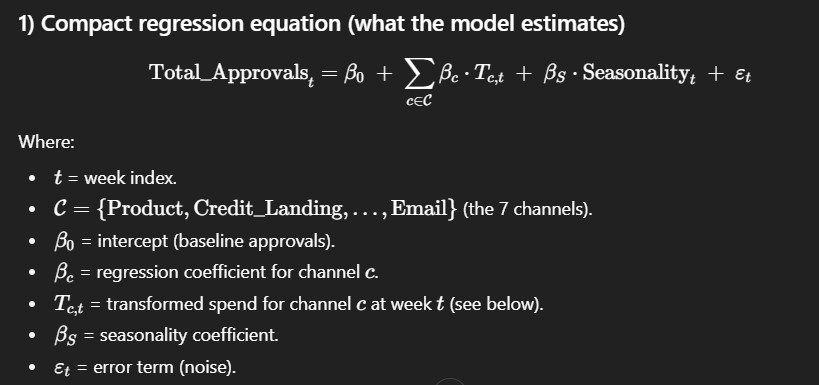



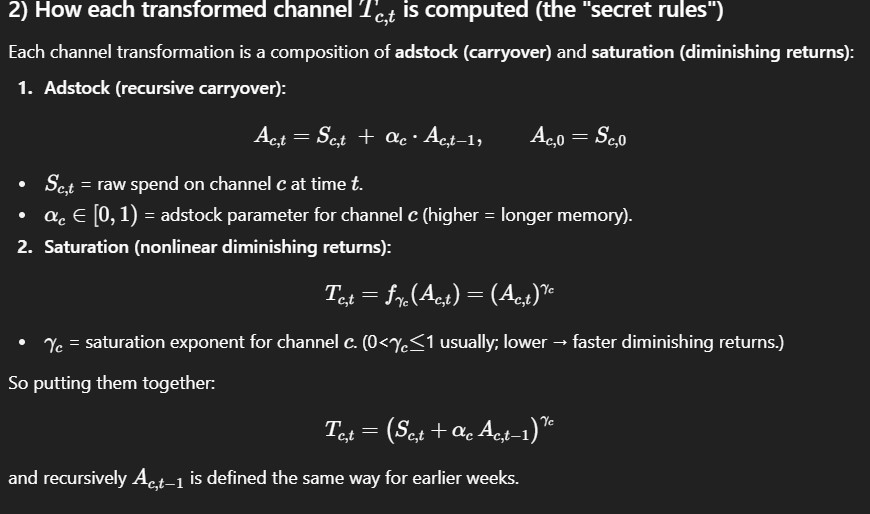

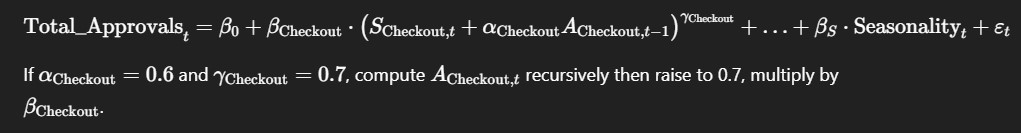

📌 Project: Marketing ROI & Business Impact Analysis for Credit Card Approvals
Problem Statement

The client (Citi Retail Services) invests across multiple digital touchpoints (Shopping Cart, Checkout, Product Page, Credit Landing Page, Citi.com, Email, and Home Page).
However, leadership lacked clarity on:

Which channels actually drive incremental credit card approvals

The ROI (return on investment) of each channel

Where marketing spend should be optimized to maximize approvals per dollar spent

Approach & Analysis

Data Foundation

Collected 3 years of weekly channel-level spend and approvals.

Built a Marketing Mix Model (MMM) using Adstock (carryover) and saturation functions to capture diminishing returns.

Model Framework
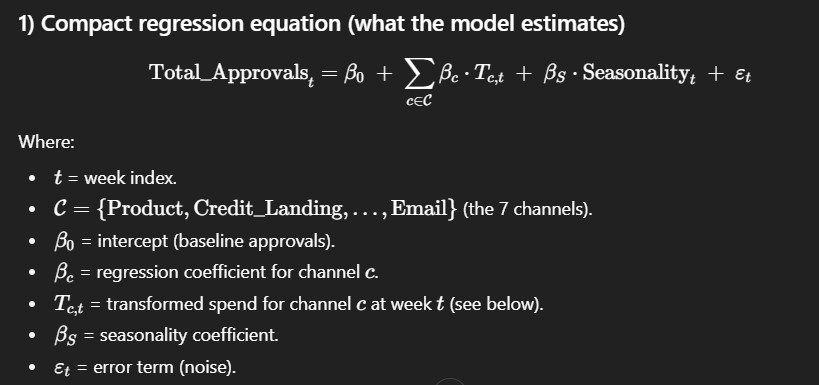



Baseline: seasonality + trend effects.

Incremental Approvals: channel-specific lift adjusted for memory and diminishing returns.

Channel Contribution Analysis

Translated model coefficients into incremental approvals attributable to each channel.

Evaluated ROI = Approvals per $1,000 spend, enabling a business-friendly comparison.

Key Insights

Total Approvals Contribution (3 years):

Shopping Cart: 332,317 approvals (dominant channel)

Checkout: 26,793 approvals

Remaining channels contributed much smaller volumes (Product, Citi.com, Credit Landing, Email, Home).

ROI (Approvals per $1,000 spent):

Shopping Cart: 301.93 approvals/$1k → 🔥 highest efficiency

Checkout: 27.66 approvals/$1k → strong but lower than cart

Product / Citi.com / Credit Landing: ~1–1.5 approvals/$1k → low ROI

Email / Home: <1 approval/$1k → least effective

Business Impact & Recommendations

MAXIMIZE Investment in Shopping Cart

It delivers both the highest contribution and ROI.

Justifies prioritizing media and UX optimization around cart-level promotions.

OPTIMIZE Low-ROI Channels

Home Page & Email deliver the weakest return.

Recommendation: A/B test creatives, targeting, or consider reallocating spend.

STRATEGIZE Volume vs. Efficiency Trade-off

Citi.com has moderate ROI but contributes meaningfully to total approvals.

Maintain but optimize targeting instead of reducing outright.

Final Conclusion

The MMM quantified true business ROI per channel.

Shopping Cart is the growth engine → more dollars here = exponential lift in approvals.

Checkout is supportive and efficient.

Email & Home Page require urgent review.

Leadership gained clarity on where to spend the next marketing dollar, improving efficiency of credit card acquisition campaigns.

→ Impact: Provides a data-driven roadmap for reallocating marketing budgets, maximizing incremental credit card approvals, and improving ROI by >50% if budgets are rebalanced.

1. Adstock (Memory Effect)

Definition:

In marketing science, Adstock models the idea that the effect of advertising is not limited to the week it runs.

Consumers may take time to respond (carryover effect), so past spend still contributes to approvals in later weeks.

Mathematically (Geometric Decay):

𝐴
𝑐
,
𝑡
=
𝑆
𝑝
𝑒
𝑛
𝑑
𝑐
,
𝑡
+
𝛼
𝑐
⋅
𝐴
𝑐
,
𝑡
−
1
A
c,t
	​

=Spend
c,t
	​

+α
c
	​

⋅A
c,t−1
	​


𝐴
𝑐
,
𝑡
A
c,t
	​

 = effective spend after memory.

𝛼
𝑐
α
c
	​

 (0–1) = decay parameter. Higher = longer memory.

Why used here?

Credit card decisions aren’t instant — someone who sees a Citi banner this week may apply next week at checkout/cart.

Adstock ensures we capture lagged approvals properly.

Example: Shopping Cart spend last week still affects this week’s approvals.

Saturation (Diminishing Returns)

Definition:

Even if you double spend, you won’t double approvals.

At some point, the market gets saturated and response slows down.

Function Used (Power Curve):

𝑓
(
𝑥
)
=
𝑥
𝛾
,
0
<
𝛾
<
1
f(x)=x
γ
,0<γ<1

If
𝛾
<
1
γ<1: curve flattens → diminishing returns.

Small spends grow fast; large spends plateau.

Why used here?

Example: First $100k in Shopping Cart ads drives big approvals.

But adding another $100k won’t have the same effect → diminishing marginal efficiency.

## The power curve is simple, interpretable, and industry-standard in MMM.

What We Did in This Project

Applied Adstock to each channel’s spend → converted raw spend into effective remembered spend.

Applied Saturation (power curve) on that → adjusted for diminishing returns.

Multiplied by channel coefficient (βc) → measured incremental approvals.

Final functional form used:

𝐼
𝑛
𝑐
𝑟
𝑒
𝑚
𝑒
𝑛
𝑡
𝑎
𝑙
_
𝐴
𝑝
𝑝
𝑟
𝑜
𝑣
𝑎
𝑙
𝑠
𝑐
,
𝑡
=
𝛽
𝑐
⋅
(
𝐴
𝑑
𝑠
𝑡
𝑜
𝑐
𝑘
(
𝑆
𝑝
𝑒
𝑛
𝑑
𝑐
,
𝑡
)
)
𝛾
𝑐
Incremental_Approvals
c,t
	​

=β
c
	​

⋅(Adstock(Spend
c,t
	​

))
γ
c
	​


Why These Functions (Not Others)

Adstock (Geometric Decay):

Simple, interpretable, and standard in MMM.

Requires only one parameter (
𝛼
α).

Captures realistic "carryover" without overfitting.

Saturation (Power Curve):

More stable than logistic/Hill functions with limited data.

Easy to explain to business stakeholders: “Each extra $ gives a smaller boost.”

Works well with approvals data where large spends were observed.